In [1]:
!pip install triton

In [3]:
"""
For matmul of A @ B = C of shapes (M, K) @ (K, N) = (M, N)
for m in range(0, M, BLOCK_SIE_M): # do in parallel
    for n in range(0, N, BLOCK_SIZE_N): # do in parallel
        acc = zeros((BLOCK_SIZE_M, BLOCK_SIZE_N), dtype=float32)
        for k in range(0, K, BLOCK_SIZE_K):
            a = A[m : m+BLOCK_SIZE_M, k : k+BLOCK_SIZE_K]
            b = B[k : k+BLOCK_SIZE_K, n : n+BLOCK_SIZE_N]
            acc += dot(a,b)
        C[m : m+BLOCK_SIZE_M, n : n+BLOCK_SIZE_N] = acc

Normal matmul would do a loop over entire row and column instead of doing it in parallel 
"""
import torch
import triton
import triton.language as tl
DEVICE = torch.device(f'cuda:{torch.cuda.current_device()}')

# import os
# os.environ['TRITON_INTERPRET'] = '1' # uses python interpreter instead of compiling to PTX, helps to debug by writing print statements and python debugger in the kernel


#step 3:
# num_stages = how many things we can do in parallel. doesnt work if the operations are sequential

autotune_configs = [
    triton.Config({'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 256, 'BLOCK_SIZE_K': 64, 'GROUP_SIZE': 8}, num_stages=3, num_warps=8),
    triton.Config({'BLOCK_SIZE_M': 64, 'BLOCK_SIZE_N': 256, 'BLOCK_SIZE_K': 32, 'GROUP_SIZE': 8}, num_stages=4, num_warps=4),
    triton.Config({'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 128, 'BLOCK_SIZE_K': 32, 'GROUP_SIZE': 8}, num_stages=4, num_warps=4),
    triton.Config({'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 64, 'BLOCK_SIZE_K': 32, 'GROUP_SIZE': 8}, num_stages=4, num_warps=4),
    triton.Config({'BLOCK_SIZE_M': 64, 'BLOCK_SIZE_N': 128, 'BLOCK_SIZE_K': 32, 'GROUP_SIZE': 8}, num_stages=4, num_warps=4),
    triton.Config({'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 32, 'BLOCK_SIZE_K': 32, 'GROUP_SIZE': 8}, num_stages=4, num_warps=4),
    triton.Config({'BLOCK_SIZE_M': 64, 'BLOCK_SIZE_N': 32, 'BLOCK_SIZE_K': 32, 'GROUP_SIZE': 8}, num_stages=5, num_warps=2),
    triton.Config({'BLOCK_SIZE_M': 32, 'BLOCK_SIZE_N': 64, 'BLOCK_SIZE_K': 32, 'GROUP_SIZE': 8}, num_stages=5, num_warps=2)
]

@triton.autotune(configs=autotune_configs, key=['M', 'N', 'K'])
@triton.jit
def _matmul_kernel(
    a_ptr, b_ptr, c_ptr,
    M, N, K,
    stride_am, stride_ak,
    stride_bk, stride_bn,
    stride_cm, stride_cn,
    BLOCK_SIZE_M: tl.constexpr,
    BLOCK_SIZE_N: tl.constexpr,
    BLOCK_SIZE_K: tl.constexpr,
    GROUP_SIZE: tl.constexpr,
):

# we start with a 1D launch grid that we will turn into a 2D grid with a complicated "group-wise" ordering
    PID = tl.program_id(axis=0) 
    # defining the size of groups
    num_PID_along_M = tl.cdiv(M, BLOCK_SIZE_M) # the number of blocks along M dimension
    num_PID_along_N = tl.cdiv(N, BLOCK_SIZE_N) # the number of blocks along N dimension
    num_PID_in_group = GROUP_SIZE * num_PID_along_N
    # figurinig out which group this PID is in
    group_id = PID // num_PID_in_group 
    # tells us which row to start at for this group
    first_PID_in_group_along_M = group_id * GROUP_SIZE 
    # this is usually equal to GROUP_SIZE; the alternative case happens when we're at edge of the tensor and 
    #  its dimensions don't cleanly divde into GROUP_SIZE # TODO is this true?
    group_size_adj = min(num_PID_along_M - first_PID_in_group_along_M, GROUP_SIZE) 
    # this is the bulk of the actual mapping of PIDs to group-major ordering
    PID_M = first_PID_in_group_along_M + ((PID % num_PID_in_group) % group_size_adj)
        # (PID % num_PID_in_group) puts the current program id into the context of a group
        # (first_PID_in_group_along_m + ...) shifts the PID into the correct group
        # (... % group_size_adj) removes the column component to get us onto the correct row
    PID_N = (PID % num_PID_in_group) // group_size_adj
        # (... // group_size_adj) removes the row component to get us onto the correct column

    offsets_M = PID_M * BLOCK_SIZE_M + tl.arange(0, BLOCK_SIZE_M)
    offsets_N = PID_N * BLOCK_SIZE_N + tl.arange(0, BLOCK_SIZE_N)
    offsets_K = tl.arange(0, BLOCK_SIZE_K)
    # in previous lessons the blocks we loaded into SRAM were vectors; here they are matrices
    a_offsets = offsets_M[:, None] * stride_am + offsets_K[None, :] * stride_ak
    b_offsets = offsets_K[:, None] * stride_bk + offsets_N[None, :] * stride_bn

    accumulator = tl.zeros((BLOCK_SIZE_M, BLOCK_SIZE_N), dtype=tl.float32) # the full C is shape (M, N)
        # for a demonstration of why accumulation works, check out `./block_wise_matmul.png`
        
    # we'll iterate along the K dimension of both A and B to compute a single block of the C matrix
    for k in range(0, tl.cdiv(K, BLOCK_SIZE_K)):
        # out-of-bounds entries (along K) need to be masked out
        mask = offsets_K < K - k * BLOCK_SIZE_K
            # k * BLOCK_SIZE_K is the current starting index of offsets_k.
            # so this only really activates when k is within BLOCK_SIZE_K entries from K
            # meaning this gets triggered on the last iteration of the loop, and only if K is not a multiple of BLOCK_SIZE_K
        
        # Now we load blocks of A and B matrices. If multiple blocks in a group are on the same SM, 
        # they can share these loaded values, which reduces the number of expensive loads from DRAM
        a = tl.load(a_ptr + a_offsets, mask=mask[None, :], other=0.0) # shape (BLOCK_SIZE_M, BLOCK_SIZE_K)
        b = tl.load(b_ptr + b_offsets, mask=mask[:, None], other=0.0) # shape (BLOCK_SIZE_K, BLOCK_SIZE_N)
            # fill in any masked-out parts with 0.0's since they don't have any effect on the summation in the next step

        # we accumulate along the K dimension
        accumulator = tl.dot(a, b, acc=accumulator)
            # `acc` tells Triton to write the output of the matmul directly to accumulator, which is more efficient than
            #   accumulator += tl.dot(a, b)

        # advance the pointers to the next block along K
        a_offsets += BLOCK_SIZE_K * stride_ak
        b_offsets += BLOCK_SIZE_K * stride_bk

    accumulator = accumulator.to(tl.float16)

    # write back the block of the output matrix C with masks
    c_offsets = stride_cm * offsets_M[:, None] + stride_cn * offsets_N[None, :] 
    c_mask = (offsets_M[:, None] < M) & (offsets_N[None, :] < N) # notice the 2D mask
    tl.store(c_ptr + c_offsets, accumulator, mask=c_mask) # shape (BLOCK_SIZE_M, BLOCK_SIZE_N)




#step 2
def matmul(a, b):
    assert a.ndim == 2 and b.ndim == 2
    assert a.shape[1] == b.shape[0]
    
    (M,K),(_,N) = a.shape, b.shape

    c = torch.empty((M,N), device=a.device, dtype=a.dtype)

    grid = lambda meta: (triton.cdiv(M, meta['BLOCK_SIZE_M']) * triton.cdiv(N, meta['BLOCK_SIZE_N']),)
    _matmul_kernel[grid](
        a,b,c,
        M,N,K,
        a.stride(0), a.stride(1),
        b.stride(0), b.stride(1),
        c.stride(0), c.stride(1),
    )
    return c

# Step 1 
def test_matmul_kernel(size: tuple, atol=1e-2, rtol=1e-1, device=DEVICE):
    """
    We use higher tolerance values than previous tests because all the flop 
    accumulation can really compound when it comes to a matmul; even slight
    differences in the block size and launch grid ordering from what PyTorch 
    does can result in pretty sizeable discrepancies
    """
    # create input data
    torch.manual_seed(0)
    assert type(size) == tuple and len(size) == 2
    a = torch.randn((512, 512), device=DEVICE, dtype=torch.float16)
    b = torch.randn((512, 512), device=DEVICE, dtype=torch.float16)
    # run kernel & pytorch reference implementation
    c_tri = matmul(a, b)
    c_ref = torch.matmul(a, b)
    # compare
    torch.testing.assert_close(c_tri, c_ref, atol=atol, rtol=rtol)
    print("PASSED")


######### Step 4 #########
configs = [
    triton.testing.Benchmark(
        x_names = ["M", "N", "K"], # we can increase multiple dimensions simultaneously while benchmarking
        x_vals = [128 * i for i in range(2, 33)],
        line_arg = "provider", 
        line_vals = ["torch", "triton"],
        line_names = ["PyTorch", "Triton"],
        styles = [("green", "-"), ("blue", "-")],
        ylabel = "TFLOPS", 
        plot_name = "matmul-performance",
        args={},
    )
]
@triton.testing.perf_report(configs)
def benchmark(M, N, K, provider):
    a = torch.randn((M, K), device=DEVICE, dtype=torch.float16)
    b = torch.randn((K, N), device=DEVICE, dtype=torch.float16)
    quantiles = [0.5, 0.05, 0.95]
    if provider == 'torch':
        ms, min_ms, max_ms = triton.testing.do_bench(lambda: torch.matmul(a, b), quantiles=quantiles)
    if provider == 'triton':
        ms, min_ms, max_ms = triton.testing.do_bench(lambda: matmul(a, b), quantiles=quantiles)
    perf = lambda ms: 3 * M * N * K * 1e-12 / (ms * 1e-3)
        # 3 = number of memory operations (2 read + 1 write)
        # M * N * K = number of elements per memory op
        # 1e-12 converts flops to Teraflops
        # 1e-3 converts milliseconds to seconds
    return perf(ms), perf(max_ms), perf(min_ms)

if __name__ == "__main__":
    # always run unit-tests
    test_matmul_kernel(size=(1024, 1024))

    # Only run benchmark if explicitly requested
    import sys
    if len(sys.argv) > 1 and sys.argv[1] == "--benchmark":
        benchmark.run(save_path='.', print_data=False)

PASSED


matmul-performance:
         M       N       K  PyTorch (TFLOPS)  Triton (TFLOPS)
0    256.0   256.0   256.0          2.166479         0.719517
1    384.0   384.0   384.0          9.313010         2.506334
2    512.0   512.0   512.0         20.393699         2.594147
3    640.0   640.0   640.0         28.199656         2.145813
4    768.0   768.0   768.0         41.170459         2.227970
5    896.0   896.0   896.0         35.927834         2.195057
6   1024.0  1024.0  1024.0         47.060915         2.051004
7   1152.0  1152.0  1152.0         39.375613         1.966444
8   1280.0  1280.0  1280.0         41.365032         1.989325
9   1408.0  1408.0  1408.0         42.759027         2.017308
10  1536.0  1536.0  1536.0         46.533162         2.044481
11  1664.0  1664.0  1664.0         38.710201         1.952315
12  1792.0  1792.0  1792.0         41.608233         1.930730
13  1920.0  1920.0  1920.0         42.256384         1.775713
14  2048.0  2048.0  2048.0         36.297952      

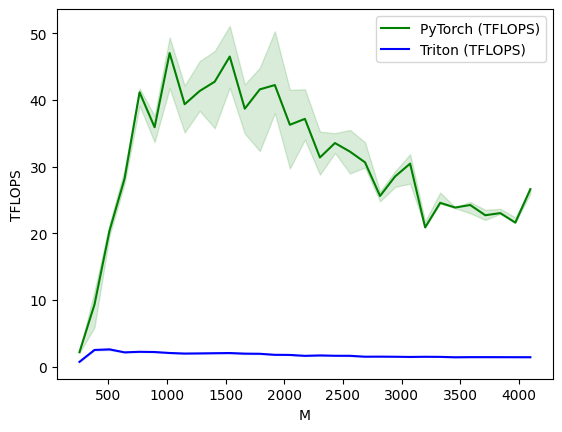

In [5]:
benchmark.run(save_path='.', print_data=True)